In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("exchange_rate.csv")
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y %H:%M")
df.set_index("date",inplace=True)
print(df.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


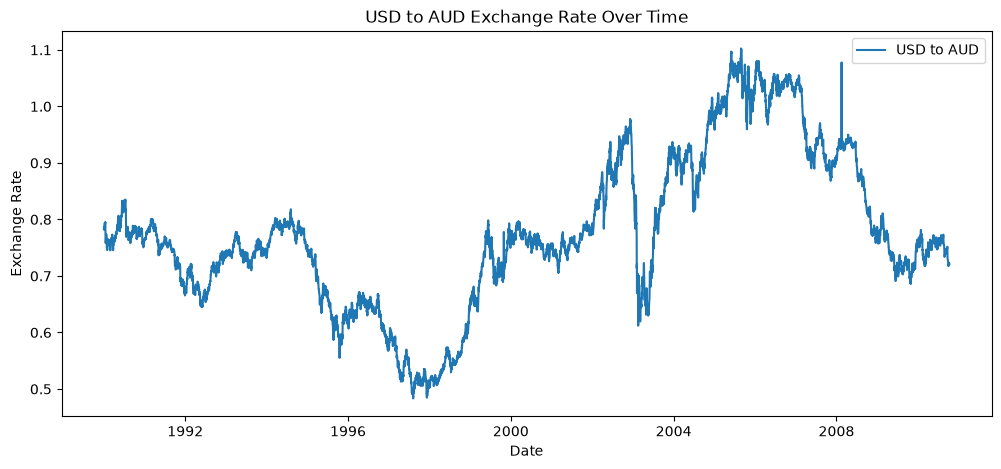

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df.index,df.iloc[:,0],label="USD to AUD")
plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [5]:
print(df.isna().sum())
df.ffill(inplace=True)
print(df.isna().sum())

Ex_rate    0
dtype: int64
Ex_rate    0
dtype: int64


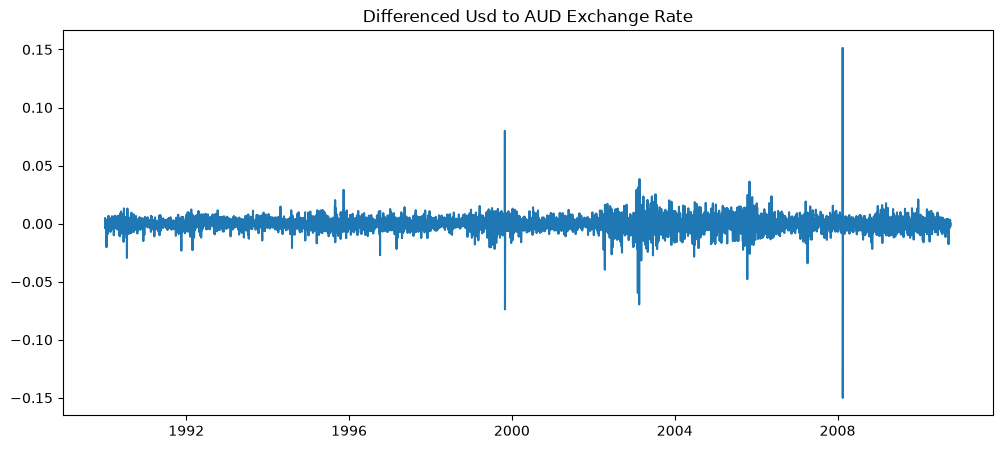

In [6]:
diff_series=df.iloc[:,0].diff().dropna()
plt.figure(figsize=(12,5))
plt.plot(diff_series)
plt.title("Differenced Usd to AUD Exchange Rate")
plt.show()

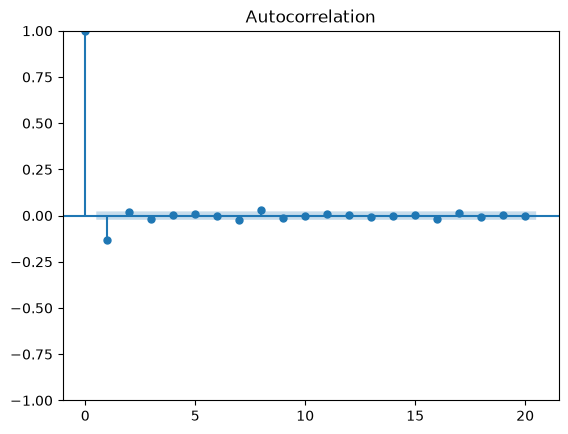

In [7]:
plot_acf(diff_series, lags=20)
plt.show()

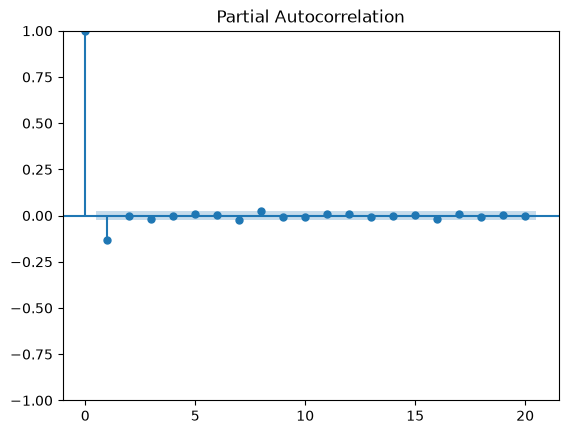

In [8]:
plot_pacf(diff_series, lags=20)
plt.show()

In [9]:
train_size=int(len(df)*0.8)
train, test= df.iloc[:train_size,0],df.iloc[train_size:,0]
print(train,test)

date
1990-01-01    0.785500
1990-01-02    0.781800
1990-01-03    0.786700
1990-01-04    0.786000
1990-01-05    0.784900
                ...   
2006-08-10    1.022620
2006-08-11    1.027591
2006-08-12    1.022349
2006-08-13    1.023395
2006-08-14    1.023552
Name: Ex_rate, Length: 6070, dtype: float64 date
2006-08-15    1.025347
2006-08-16    1.026905
2006-08-17    1.037344
2006-08-18    1.038875
2006-08-19    1.032855
                ...   
2010-10-06    0.718494
2010-10-07    0.721839
2010-10-08    0.723197
2010-10-09    0.720825
2010-10-10    0.720825
Name: Ex_rate, Length: 1518, dtype: float64


In [10]:
model=ARIMA(train, order=(1,1,1,))
model_fit=model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Tue, 07 Jul 2026   AIC                         -45432.092
Time:                        18:54:44   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

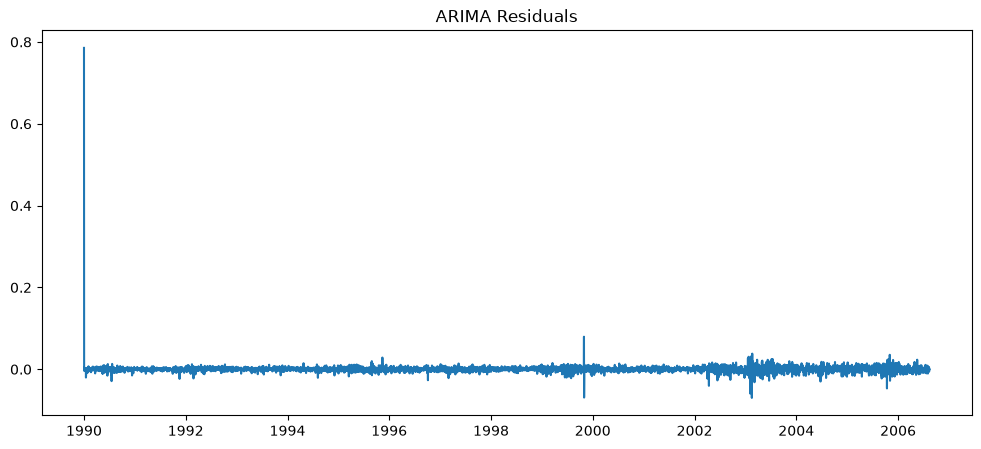

In [11]:
residuals = model_fit.resid
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

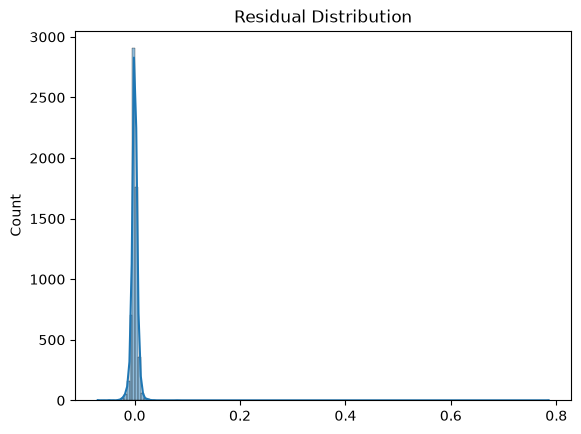

In [12]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

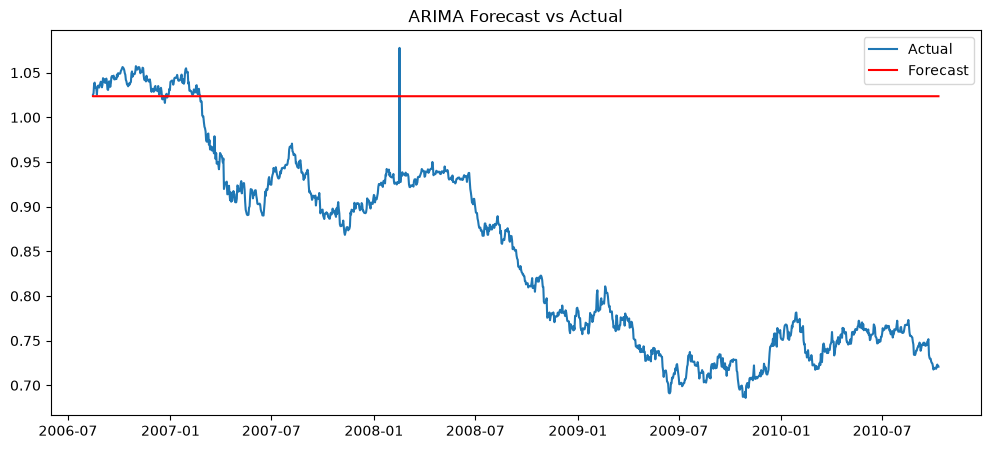

In [13]:
forecast = model_fit.forecast(steps=len(test))
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast", color='red')
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

In [14]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100
print("ARIMA Model Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

ARIMA Model Performance:
MAE : 0.17770970449121345
RMSE: 0.2054366965966928
MAPE: 22.797966173811552


In [15]:
naive_forecast = test.shift(1).dropna()
actual = test[1:]
mae_n = mean_absolute_error(actual, naive_forecast)
rmse_n = np.sqrt(mean_squared_error(actual, naive_forecast))
mape_n = np.mean(np.abs((actual - naive_forecast) / actual)) * 100
print("\nNaive Model Performance:")
print("MAE :", mae_n)
print("RMSE:", rmse_n)
print("MAPE:", mape_n)


Naive Model Performance:
MAE : 0.003288294001318392
RMSE: 0.007147056221099313
MAPE: 0.3914891109336043
